# IMPROVE First-Order Loading Range Analysis

This notebook reframes the IMPROVE/FED comparison around the first-order question from the April discussion:

> Are the Addis/ETAD HIPS filters in a measurement regime that IMPROVE actually samples, when we compare `fAbs`, EC mass on the filter, and EC surface loading separately?

The workflow starts with the full IMPROVE baseline for samples with `year >= 2003` before applying ETAD/Addis bounds. This follows the paper/IMPROVE-meeting language that calibrated HIPS/Fabs data are consistent from “2003-present” / “since 2003”; `2003-01-01` is only the code boundary used to implement that annual cutoff, not a claimed exact instrument-change date. The main comparison uses robust ETAD 5th-95th percentile ranges; full min-max ranges are retained as an audit so isolated extremes are visible but do not define the primary result.

## Analysis Questions

1. What does the full stable-period IMPROVE population look like before any ETAD/Addis screening?
2. Which ETAD/Addis range is most restrictive in IMPROVE: `fAbs`, EC mass loading, or EC surface loading?
3. Do IMPROVE filters with ETAD/Addis-like loading also occupy the ETAD/Addis `fAbs` regime?
4. Within bounded groups, does `fAbs` vs EC preserve a meaningful relationship, or does the high-`fAbs` tail behave like rare/event-like outliers?
5. What can the FED RT fields tell us, and what remains impossible without raw blank/coefficient records?

## Date-Cutoff Source Note

The stable-period cutoff should be cited as an annual cutoff, not an exact day. The supporting language found in the IMPROVE materials is:

- IMPROVE Steering Committee 2015 minutes: Warren White presented that HIPS data are reported with consistent calibration for `2003-present`.
- White et al. 2016: the abstract/snippet describes an inferred `2002-2003` HIPS response change.
- White et al. 2024/2025 patterned-deposit paper and related meeting material: archived-sample reanalysis supports stable calibration `since 2003`, with 2003-2016 lots used in the reanalysis context.

Therefore this notebook uses `Date >= 2003-01-01` as a reproducible implementation of `year >= 2003`. If a later paper/source gives a month-specific transition, update `STABLE_START` and rerun.


In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Notebook lives in research/improve_hips_offset.
PROJECT_DIR = Path('/Users/ahmadjalil/github/aethmodular')
SPARTAN_DIR = PROJECT_DIR / 'research' / 'ftir_hips_chem'
IMPROVE_PREV_OUT = SPARTAN_DIR / 'output' / 'improve_high_fabs_comparison'
OUT_DIR = PROJECT_DIR / 'research' / 'improve_hips_offset' / 'output' / 'improve_first_order_loading_range_analysis'
OUT_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(SPARTAN_DIR / 'scripts'))
from config import MAC_VALUE
from outliers import apply_exclusion_flags, apply_threshold_flags
from plotting import apply_default_style

apply_default_style()
warnings.filterwarnings('ignore', category=FutureWarning)

STABLE_START = pd.Timestamp('2003-01-01')
PRIMARY_IMPROVE_AREA_CM2 = 3.5
SPARTAN_FILTER_PATH = SPARTAN_DIR / 'Filter Data' / 'unified_filter_dataset.pkl'
IMPROVE_CLEAN_PATH = IMPROVE_PREV_OUT / 'improve_valid_cleaned.csv'

SITE_CODE_TO_NAME = {
    'CHTS': 'Beijing',
    'INDH': 'Delhi',
    'USPA': 'JPL',
    'ETAD': 'Addis_Ababa',
}
SITE_ORDER = ['Beijing', 'Delhi', 'JPL', 'Addis_Ababa']
MIN_EC = 0.0

print(f'Output directory: {OUT_DIR}')

Output directory: /Users/ahmadjalil/github/aethmodular/research/improve_hips_offset/output/improve_first_order_loading_range_analysis


## Rebuild ETAD/Addis Reference Ranges

The SPARTAN reference is rebuilt from the local unified filter dataset so the bounds reflect the same exclusion registry used elsewhere in this project. EC loading is taken from the EC row mass loading, then divided by the measured SPARTAN deposit area.

In [2]:
def rebuild_spartan_reference():
    df_long = pd.read_pickle(SPARTAN_FILTER_PATH)
    df_long['SampleDate'] = pd.to_datetime(df_long['SampleDate'], errors='coerce')
    df_long['SiteName'] = df_long['Site'].map(SITE_CODE_TO_NAME)

    pivot_params = [
        'EC_ftir', 'HIPS_Fabs', 'HIPS_tau', 'HIPS_T1', 'HIPS_R1',
        'HIPS_t', 'HIPS_r', 'ChemSpec_OC_PM2.5', 'ChemSpec_Filter_PM2.5_mass',
    ]
    wide = (
        df_long[df_long['Parameter'].isin(pivot_params)]
        .pivot_table(
            index=['Site', 'SiteName', 'FilterId', 'SampleDate', 'FilterType', 'LotId', 'DepositArea_cm2', 'Volume_m3'],
            columns='Parameter',
            values='Concentration',
            aggfunc='first',
        )
        .reset_index()
    )
    wide.columns.name = None

    ec_mass = (
        df_long[df_long['Parameter'].eq('EC_ftir')][['FilterId', 'MassLoading_ug']]
        .drop_duplicates('FilterId')
        .rename(columns={'MassLoading_ug': 'EC_loading_ug'})
    )
    wide = wide.merge(ec_mass, on='FilterId', how='left')
    wide['HIPS_BC'] = wide['HIPS_Fabs'] / MAC_VALUE
    wide['EC_loading_ug_cm2'] = wide['EC_loading_ug'] / wide['DepositArea_cm2']
    wide['t_plus_r'] = wide.get('HIPS_t', np.nan) + wide.get('HIPS_r', np.nan)

    clean_frames = []
    for site_name in SITE_ORDER:
        site_code = [code for code, label in SITE_CODE_TO_NAME.items() if label == site_name][0]
        site_df = wide[(wide['Site'].eq(site_code)) & (wide['FilterType'].eq('PM2.5'))].copy()
        site_df['aeth_bc'] = pd.NA
        site_df['filter_ec'] = site_df['EC_ftir'] * 1000.0
        site_df['date'] = site_df['SampleDate']
        site_df['filter_id'] = site_df['FilterId']
        site_df = apply_exclusion_flags(site_df, site_name)
        site_df = apply_threshold_flags(site_df, site_name)
        clean = site_df[
            (~site_df['is_excluded'])
            & (~site_df['is_outlier'])
            & site_df['EC_ftir'].notna()
            & site_df['HIPS_Fabs'].notna()
            & site_df['EC_loading_ug'].notna()
            & site_df['EC_loading_ug_cm2'].notna()
            & (site_df['EC_ftir'] >= MIN_EC)
        ].copy()
        clean_frames.append(clean)

    clean_pm25 = pd.concat(clean_frames, ignore_index=True)
    return clean_pm25

spartan = rebuild_spartan_reference()
etad = spartan[spartan['SiteName'].eq('Addis_Ababa')].copy()

range_vars = {
    'fAbs_Mm-1': 'HIPS_Fabs',
    'EC_ug_m3': 'EC_ftir',
    'EC_loading_ug_filter': 'EC_loading_ug',
    'EC_loading_ug_cm2': 'EC_loading_ug_cm2',
}

bounds = []
for label, col in range_vars.items():
    s = etad[col].dropna()
    bounds.append({
        'metric': label,
        'n': int(s.size),
        'min': s.min(),
        'p05': s.quantile(0.05),
        'p25': s.quantile(0.25),
        'median': s.median(),
        'p75': s.quantile(0.75),
        'p95': s.quantile(0.95),
        'max': s.max(),
    })

etad_bounds = pd.DataFrame(bounds)
etad_bounds.to_csv(OUT_DIR / 'etad_reference_bounds.csv', index=False)
display(etad_bounds.round(3))

,metric,n,min,p05,p25,median,p75,p95,max
0,fAbs_Mm-1,190,28.086,34.681,41.282,47.132,55.707,68.043,85.853
1,EC_ug_m3,190,0.693,2.365,3.295,4.625,6.638,9.600,11.735
2,EC_loading_ug_filter,190,4.871,16.680,23.875,33.504,47.619,69.329,82.465
3,EC_loading_ug_cm2,190,1.380,4.725,6.763,9.491,13.490,19.640,23.361


## Load IMPROVE Cleaned FED Pull

This uses the cleaned FED export from `improve_high_fabs_comparison.ipynb` instead of reparsing the workbooks. That table already contains positive EC and `fAbs` rows, flow/duration-derived volume, EC loading, site metadata, and the available RT fields.

In [3]:
usecols = [
    'Dataset', 'SiteCode', 'POC', 'Date', 'AuxID',
    'ECf_Val', 'OCf_Val', 'fAbs_Val', 'FlowRate_Val', 'SampDur_Val',
    'FEf_Val', 'MF_Val', 'SOILf_Val',
    'volume_m3', 'EC_loading_ug', 'MF_loading_ug',
    'EC_loading_ug_cm2_area_2p2', 'EC_loading_ug_cm2_area_3p5', 'EC_loading_ug_cm2_area_4p0',
    'EC_loading_ug_cm2_primary', 'fAbs_per_EC', 'OC_EC', 'FE_EC', 'SOIL_EC', 'MF_EC',
    'year', 'month', 'year_month', 'SiteName', 'Country', 'State', 'County', 'Latitude', 'Longitude',
    'RefF_635_Val', 'TransF_635_Val', 'RefI_635_Val', 'TransI_635_Val', 'RefM_635_Val', 'TransM_635_Val', 'rt_available',
]

improve = pd.read_csv(IMPROVE_CLEAN_PATH, usecols=lambda c: c in set(usecols), parse_dates=['Date'])
for col in ['year', 'month']:
    if col not in improve.columns:
        improve[col] = getattr(improve['Date'].dt, col)

improve['post_2003'] = improve['Date'].ge(STABLE_START)
improve['valid_loading'] = improve['EC_loading_ug'].notna() & improve['EC_loading_ug_cm2_primary'].notna()
improve['rt_available'] = improve['rt_available'].fillna(False).astype(bool)
post = improve[improve['post_2003']].copy()

print(f'Cleaned positive EC + fAbs rows, all years: {len(improve):,}')
print(f'Post-2003 rows: {len(post):,}')
print(f'Post-2003 rows with valid EC loading: {post["valid_loading"].sum():,}')
print(f'Post-2003 rows with RT fields: {post["rt_available"].sum():,}')
display(post[['ECf_Val', 'fAbs_Val', 'volume_m3', 'EC_loading_ug', 'EC_loading_ug_cm2_primary']].describe(percentiles=[.05, .25, .5, .75, .95, .99]).T.round(3))

Cleaned positive EC + fAbs rows, all years: 379,697
Post-2003 rows: 379,697
Post-2003 rows with valid EC loading: 152,029
Post-2003 rows with RT fields: 147,380


,count,mean,std,min,5%,25%,50%,75%,95%,99%,max
ECf_Val,379697.0,0.205,0.365,0.000,0.017,0.059,0.121,0.241,0.622,1.410,43.760
fAbs_Val,379697.0,2.244,2.601,0.000,0.190,0.710,1.510,2.940,6.380,12.430,310.950
volume_m3,152029.0,30.425,0.788,10.293,29.300,30.082,30.521,30.870,31.388,31.799,37.084
EC_loading_ug,152029.0,5.609,12.078,0.000,0.449,1.583,3.230,6.373,16.719,40.396,1047.936
EC_loading_ug_cm2_primary,152029.0,1.603,3.451,0.000,0.128,0.452,0.923,1.821,4.777,11.542,299.410


## Stable-Period Baseline Before Screening

This is the view to keep in front of the interpretation: IMPROVE is a large network dataset, and ETAD/Addis-like filters are sought within that full post-2003 baseline rather than by starting with a high-`fAbs` threshold.

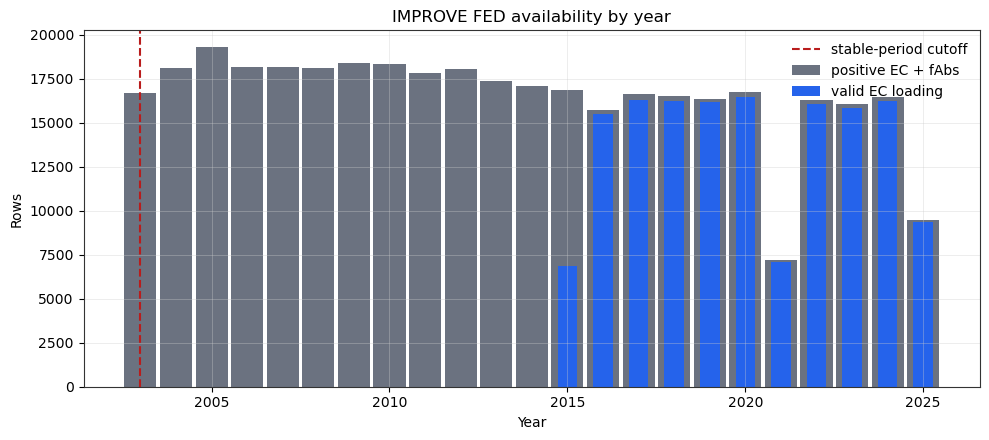

,year,period,rows,loading_rows,rt_rows,sites
13,2016,post_2003,15736,15472,15736,154
14,2017,post_2003,16640,16269,16640,156
15,2018,post_2003,16505,16211,16505,155
16,2019,post_2003,16344,16175,16344,158
17,2020,post_2003,16730,16479,16730,159
18,2021,post_2003,7214,7098,7214,159
19,2022,post_2003,16277,16058,16277,156
20,2023,post_2003,16027,15853,16027,153
21,2024,post_2003,16444,16232,16444,152
22,2025,post_2003,9463,9353,9463,153


In [4]:
year_counts = (
    improve.assign(period=np.where(improve['post_2003'], 'post_2003', 'pre_2003'))
    .groupby(['year', 'period'])
    .agg(
        rows=('fAbs_Val', 'size'),
        loading_rows=('valid_loading', 'sum'),
        rt_rows=('rt_available', 'sum'),
        sites=('SiteCode', 'nunique'),
    )
    .reset_index()
)
year_counts.to_csv(OUT_DIR / 'improve_yearly_availability.csv', index=False)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(year_counts['year'], year_counts['rows'], color='#6B7280', width=0.9, label='positive EC + fAbs')
ax.bar(year_counts['year'], year_counts['loading_rows'], color='#2563EB', width=0.55, label='valid EC loading')
ax.axvline(2003, color='#B91C1C', lw=1.5, ls='--', label='stable-period cutoff')
ax.set_xlabel('Year')
ax.set_ylabel('Rows')
ax.set_title('IMPROVE FED availability by year')
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUT_DIR / 'improve_yearly_availability.png', dpi=220)
plt.show()

display(year_counts.tail(10))

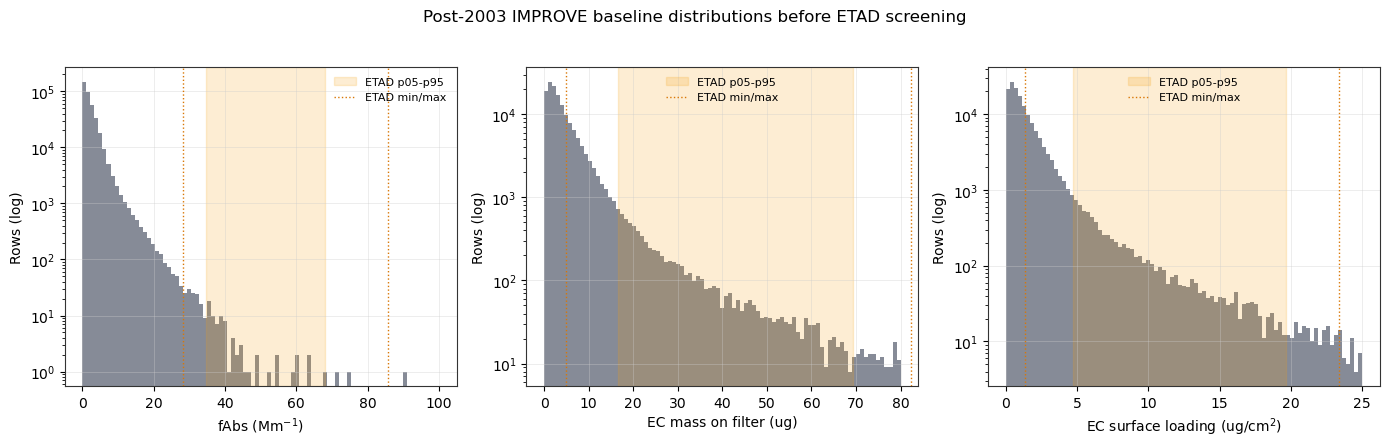

In [5]:
def metric_bounds(metric):
    row = etad_bounds.set_index('metric').loc[metric]
    return row.to_dict()

FABS = metric_bounds('fAbs_Mm-1')
EC_MASS = metric_bounds('EC_loading_ug_filter')
EC_SURFACE = metric_bounds('EC_loading_ug_cm2')
EC_CONC = metric_bounds('EC_ug_m3')

fig, axes = plt.subplots(1, 3, figsize=(14, 4.3))
plot_specs = [
    ('fAbs_Val', 'fAbs (Mm$^{-1}$)', FABS, np.linspace(0, max(100, post['fAbs_Val'].quantile(.999)), 90)),
    ('EC_loading_ug', 'EC mass on filter (ug)', EC_MASS, np.linspace(0, max(80, post['EC_loading_ug'].quantile(.995)), 90)),
    ('EC_loading_ug_cm2_primary', 'EC surface loading (ug/cm$^2$)', EC_SURFACE, np.linspace(0, max(25, post['EC_loading_ug_cm2_primary'].quantile(.995)), 90)),
]
for ax, (col, label, b, bins) in zip(axes, plot_specs):
    vals = post[col].dropna()
    ax.hist(vals, bins=bins, color='#6B7280', alpha=0.82)
    ax.axvspan(b['p05'], b['p95'], color='#F59E0B', alpha=0.18, label='ETAD p05-p95')
    ax.axvline(b['min'], color='#D97706', lw=1, ls=':', label='ETAD min/max')
    ax.axvline(b['max'], color='#D97706', lw=1, ls=':')
    ax.set_yscale('log')
    ax.set_xlabel(label)
    ax.set_ylabel('Rows (log)')
    ax.legend(frameon=False, fontsize=8)
fig.suptitle('Post-2003 IMPROVE baseline distributions before ETAD screening', y=1.03)
fig.tight_layout()
fig.savefig(OUT_DIR / 'post2003_baseline_distributions.png', dpi=220, bbox_inches='tight')
plt.show()

## Sequential ETAD/Addis Comparability Screens

The primary screen uses robust ETAD/Addis p05-p95 bounds for `fAbs`, EC mass on the filter, and EC surface loading. The exact min-max overlap is calculated separately as an audit.

In [6]:
def between(s, lo, hi):
    return s.between(lo, hi, inclusive='both')

post['in_etad_fabs_p05p95'] = between(post['fAbs_Val'], FABS['p05'], FABS['p95'])
post['in_etad_fabs_minmax'] = between(post['fAbs_Val'], FABS['min'], FABS['max'])
post['in_etad_ec_mass_p05p95'] = between(post['EC_loading_ug'], EC_MASS['p05'], EC_MASS['p95'])
post['in_etad_ec_mass_minmax'] = between(post['EC_loading_ug'], EC_MASS['min'], EC_MASS['max'])
post['in_etad_ec_surface_p05p95'] = between(post['EC_loading_ug_cm2_primary'], EC_SURFACE['p05'], EC_SURFACE['p95'])
post['in_etad_ec_surface_minmax'] = between(post['EC_loading_ug_cm2_primary'], EC_SURFACE['min'], EC_SURFACE['max'])
post['in_all_etad_p05p95'] = post['in_etad_fabs_p05p95'] & post['in_etad_ec_mass_p05p95'] & post['in_etad_ec_surface_p05p95']
post['in_all_etad_minmax'] = post['in_etad_fabs_minmax'] & post['in_etad_ec_mass_minmax'] & post['in_etad_ec_surface_minmax']

screen_steps = [
    ('cleaned positive EC + fAbs, all years', improve.index),
    ('post-2003 stable period', post.index),
    ('valid EC mass/surface loading', post[post['valid_loading']].index),
    ('ETAD fAbs p05-p95', post[post['valid_loading'] & post['in_etad_fabs_p05p95']].index),
    ('ETAD EC mass p05-p95', post[post['valid_loading'] & post['in_etad_fabs_p05p95'] & post['in_etad_ec_mass_p05p95']].index),
    ('ETAD EC surface p05-p95', post[post['valid_loading'] & post['in_etad_fabs_p05p95'] & post['in_etad_ec_mass_p05p95'] & post['in_etad_ec_surface_p05p95']].index),
]
waterfall = pd.DataFrame({'step': [s for s, _ in screen_steps], 'n': [len(idx) for _, idx in screen_steps]})
waterfall['pct_previous'] = waterfall['n'] / waterfall['n'].shift(1) * 100
waterfall['pct_initial'] = waterfall['n'] / waterfall.loc[0, 'n'] * 100
waterfall.to_csv(OUT_DIR / 'screening_waterfall_p05p95.csv', index=False)

audit_counts = pd.DataFrame([
    {'group': 'post_2003_valid_loading', 'n': int((post['valid_loading']).sum())},
    {'group': 'fAbs_minmax_only', 'n': int((post['valid_loading'] & post['in_etad_fabs_minmax']).sum())},
    {'group': 'EC_mass_minmax_only', 'n': int((post['valid_loading'] & post['in_etad_ec_mass_minmax']).sum())},
    {'group': 'EC_surface_minmax_only', 'n': int((post['valid_loading'] & post['in_etad_ec_surface_minmax']).sum())},
    {'group': 'all_minmax', 'n': int((post['valid_loading'] & post['in_all_etad_minmax']).sum())},
    {'group': 'fAbs_p05p95_only', 'n': int((post['valid_loading'] & post['in_etad_fabs_p05p95']).sum())},
    {'group': 'EC_mass_p05p95_only', 'n': int((post['valid_loading'] & post['in_etad_ec_mass_p05p95']).sum())},
    {'group': 'EC_surface_p05p95_only', 'n': int((post['valid_loading'] & post['in_etad_ec_surface_p05p95']).sum())},
    {'group': 'all_p05p95', 'n': int((post['valid_loading'] & post['in_all_etad_p05p95']).sum())},
])
audit_counts.to_csv(OUT_DIR / 'screening_group_counts.csv', index=False)

display(waterfall.round(2))
display(audit_counts)

,step,n,pct_previous,pct_initial
0,"cleaned positive EC + fAbs, all years",379697,NaN,100.00
1,post-2003 stable period,379697,100.00,100.00
2,valid EC mass/surface loading,152029,40.04,40.04
3,ETAD fAbs p05-p95,36,0.02,0.01
4,ETAD EC mass p05-p95,10,27.78,0.00
5,ETAD EC surface p05-p95,10,100.00,0.00


,group,n
0,post_2003_valid_loading,152029
1,fAbs_minmax_only,77
2,EC_mass_minmax_only,51860
3,EC_surface_minmax_only,52319
4,all_minmax,42
5,fAbs_p05p95_only,36
6,EC_mass_p05p95_only,7196
7,EC_surface_p05p95_only,7299
8,all_p05p95,10


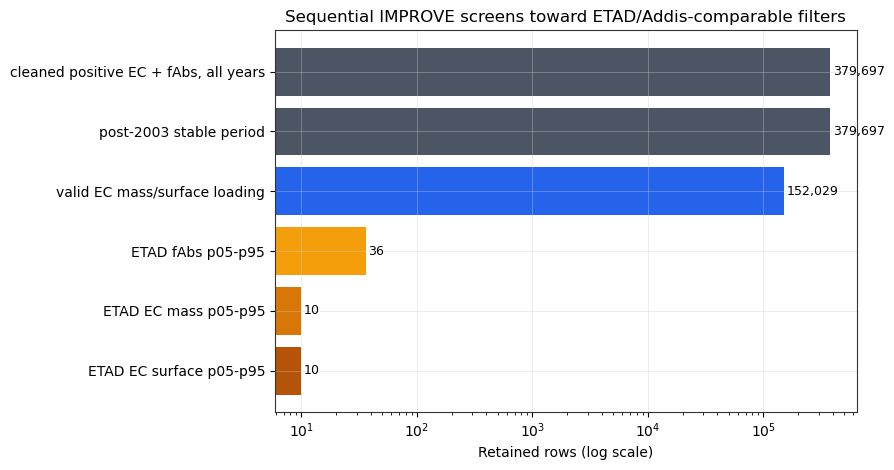

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.8))
colors = ['#4B5563', '#4B5563', '#2563EB', '#F59E0B', '#D97706', '#B45309']
ax.barh(waterfall['step'][::-1], waterfall['n'][::-1], color=colors[::-1])
ax.set_xscale('log')
ax.set_xlabel('Retained rows (log scale)')
ax.set_title('Sequential IMPROVE screens toward ETAD/Addis-comparable filters')
for i, (_, row) in enumerate(waterfall.iloc[::-1].iterrows()):
    ax.text(row['n'] * 1.05, i, f"{int(row['n']):,}", va='center', fontsize=9)
fig.tight_layout()
fig.savefig(OUT_DIR / 'screening_waterfall_p05p95.png', dpi=220, bbox_inches='tight')
plt.show()

## Where Are the Comparable Filters?

These summaries show whether retained filters are a network-wide population or a handful of site/month events.

In [8]:
comparable = post[post['valid_loading'] & post['in_all_etad_p05p95']].copy()
comparable_minmax = post[post['valid_loading'] & post['in_all_etad_minmax']].copy()

site_counts = (
    comparable.groupby(['SiteCode', 'SiteName', 'State', 'Country'], dropna=False)
    .agg(n=('fAbs_Val', 'size'), first_date=('Date', 'min'), last_date=('Date', 'max'), median_fAbs=('fAbs_Val', 'median'), median_EC=('ECf_Val', 'median'))
    .sort_values('n', ascending=False)
    .reset_index()
)
site_counts.to_csv(OUT_DIR / 'all_bounds_p05p95_site_counts.csv', index=False)
comparable.to_csv(OUT_DIR / 'all_bounds_p05p95_rows.csv', index=False)
comparable_minmax.to_csv(OUT_DIR / 'all_bounds_minmax_rows.csv', index=False)

print(f'All p05-p95 bounds rows: {len(comparable):,}')
print(f'All min-max bounds rows: {len(comparable_minmax):,}')
display(site_counts.head(20))

All p05-p95 bounds rows: 10
All min-max bounds rows: 42


,SiteCode,SiteName,State,Country,n,first_date,last_date,median_fAbs,median_EC
0,NOGA1,Nogales,AZ,US,3,2017-11-24,2024-12-20,35.820,2.15927
1,PHOE1,Phoenix,AZ,US,2,2016-01-01,2025-01-01,40.465,2.02874
2,CACR1,Caney Creek,AR,US,1,2024-02-24,2024-02-24,37.200,1.03405
3,FRES1,Fresno,CA,US,1,2023-11-26,2023-11-26,35.810,3.08624
4,PHOE5,Phoenix Colocated Sampler,AZ,US,1,2016-01-01,2016-01-01,35.600,1.98111
5,SHMI1,Shamrock Mine,CO,US,1,2024-04-24,2024-04-24,39.100,2.15766
6,SYCA2,Sycamore Canyon,AZ,US,1,2023-11-02,2023-11-02,40.270,3.98861


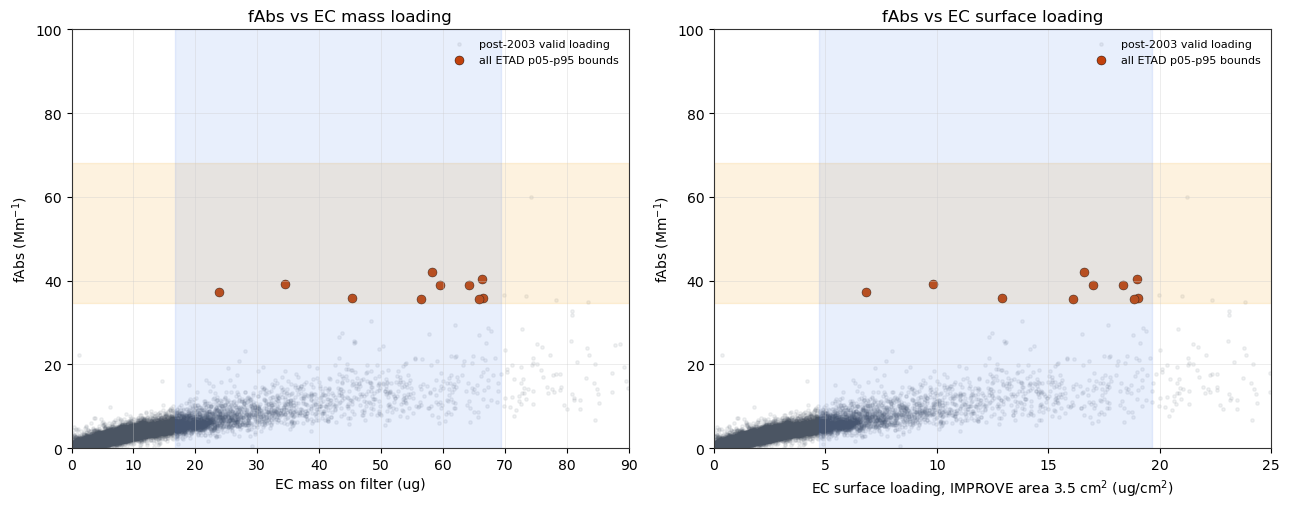

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

sample = post[post['valid_loading']].sample(min(50000, post['valid_loading'].sum()), random_state=42)
axes[0].scatter(sample['EC_loading_ug'], sample['fAbs_Val'], s=6, alpha=0.08, color='#4B5563', rasterized=True, label='post-2003 valid loading')
axes[0].scatter(comparable['EC_loading_ug'], comparable['fAbs_Val'], s=42, color='#C2410C', edgecolor='black', linewidth=0.3, label='all ETAD p05-p95 bounds')
axes[0].axhspan(FABS['p05'], FABS['p95'], color='#F59E0B', alpha=0.13)
axes[0].axvspan(EC_MASS['p05'], EC_MASS['p95'], color='#2563EB', alpha=0.10)
axes[0].set_xlabel('EC mass on filter (ug)')
axes[0].set_ylabel('fAbs (Mm$^{-1}$)')
axes[0].set_title('fAbs vs EC mass loading')
axes[0].set_xlim(0, max(90, post['EC_loading_ug'].quantile(.995)))
axes[0].set_ylim(0, max(100, post['fAbs_Val'].quantile(.999)))
axes[0].legend(frameon=False, fontsize=8)

axes[1].scatter(sample['EC_loading_ug_cm2_primary'], sample['fAbs_Val'], s=6, alpha=0.08, color='#4B5563', rasterized=True, label='post-2003 valid loading')
axes[1].scatter(comparable['EC_loading_ug_cm2_primary'], comparable['fAbs_Val'], s=42, color='#C2410C', edgecolor='black', linewidth=0.3, label='all ETAD p05-p95 bounds')
axes[1].axhspan(FABS['p05'], FABS['p95'], color='#F59E0B', alpha=0.13)
axes[1].axvspan(EC_SURFACE['p05'], EC_SURFACE['p95'], color='#2563EB', alpha=0.10)
axes[1].set_xlabel('EC surface loading, IMPROVE area 3.5 cm$^2$ (ug/cm$^2$)')
axes[1].set_ylabel('fAbs (Mm$^{-1}$)')
axes[1].set_title('fAbs vs EC surface loading')
axes[1].set_xlim(0, max(25, post['EC_loading_ug_cm2_primary'].quantile(.995)))
axes[1].set_ylim(0, max(100, post['fAbs_Val'].quantile(.999)))
axes[1].legend(frameon=False, fontsize=8)

fig.tight_layout()
fig.savefig(OUT_DIR / 'fabs_vs_loading_comparable_regions.png', dpi=230, bbox_inches='tight')
plt.show()

## fAbs vs EC Behavior in Bounded Groups

The key comparison is not a moving threshold on `fAbs`. Instead, each group has a physical interpretation: full baseline, `fAbs`-bounded only, EC-mass-bounded only, EC-surface-bounded only, and all ETAD/Addis bounds together.

In [10]:
def fit_fabs_ec(df, x_col='ECf_Val', y_col='fAbs_Val'):
    d = df[[x_col, y_col]].replace([np.inf, -np.inf], np.nan).dropna()
    d = d[(d[x_col] > 0) & (d[y_col] > 0)]
    if len(d) < 3:
        return {'n': len(d), 'slope': np.nan, 'intercept': np.nan, 'r2': np.nan, 'origin_mac': np.nan}
    x = d[x_col].to_numpy(dtype=float)
    y = d[y_col].to_numpy(dtype=float)
    slope, intercept = np.polyfit(x, y, 1)
    pred = slope * x + intercept
    ss_res = np.sum((y - pred) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    origin_mac = np.sum(x * y) / np.sum(x ** 2) if np.sum(x ** 2) > 0 else np.nan
    return {'n': len(d), 'slope': slope, 'intercept': intercept, 'r2': r2, 'origin_mac': origin_mac}

groups = {
    'post_2003_valid_loading': post[post['valid_loading']],
    'ETAD_fAbs_p05p95': post[post['valid_loading'] & post['in_etad_fabs_p05p95']],
    'ETAD_EC_mass_p05p95': post[post['valid_loading'] & post['in_etad_ec_mass_p05p95']],
    'ETAD_EC_surface_p05p95': post[post['valid_loading'] & post['in_etad_ec_surface_p05p95']],
    'all_ETAD_p05p95': comparable,
    'all_ETAD_minmax': comparable_minmax,
}

fit_rows = []
for name, df in groups.items():
    row = {'group': name, **fit_fabs_ec(df)}
    row.update({
        'sites': df['SiteCode'].nunique(),
        'fAbs_median': df['fAbs_Val'].median(),
        'ECf_median': df['ECf_Val'].median(),
        'EC_loading_ug_median': df['EC_loading_ug'].median(),
        'EC_loading_ug_cm2_median': df['EC_loading_ug_cm2_primary'].median(),
    })
    fit_rows.append(row)

fit_summary = pd.DataFrame(fit_rows)
fit_summary.to_csv(OUT_DIR / 'bounded_group_fabs_ec_fit_summary.csv', index=False)
display(fit_summary.round(3))

,group,n,slope,intercept,r2,origin_mac,sites,fAbs_median,ECf_median,EC_loading_ug_median,EC_loading_ug_cm2_median
0,post_2003_valid_loading,152029,3.656,1.296,0.403,4.714,177,1.310,0.106,3.230,0.923
1,ETAD_fAbs_p05p95,36,0.204,41.937,0.016,3.747,15,38.885,3.270,77.838,22.240
2,ETAD_EC_mass_p05p95,7196,6.962,1.709,0.511,8.493,166,7.220,0.789,23.861,6.817
3,ETAD_EC_surface_p05p95,7299,7.007,1.675,0.515,8.517,166,7.180,0.781,23.631,6.752
4,all_ETAD_p05p95,10,0.582,36.619,0.041,15.257,7,38.020,2.141,58.826,16.807
5,all_ETAD_minmax,42,6.756,20.265,0.223,14.913,17,33.225,2.282,65.459,18.702


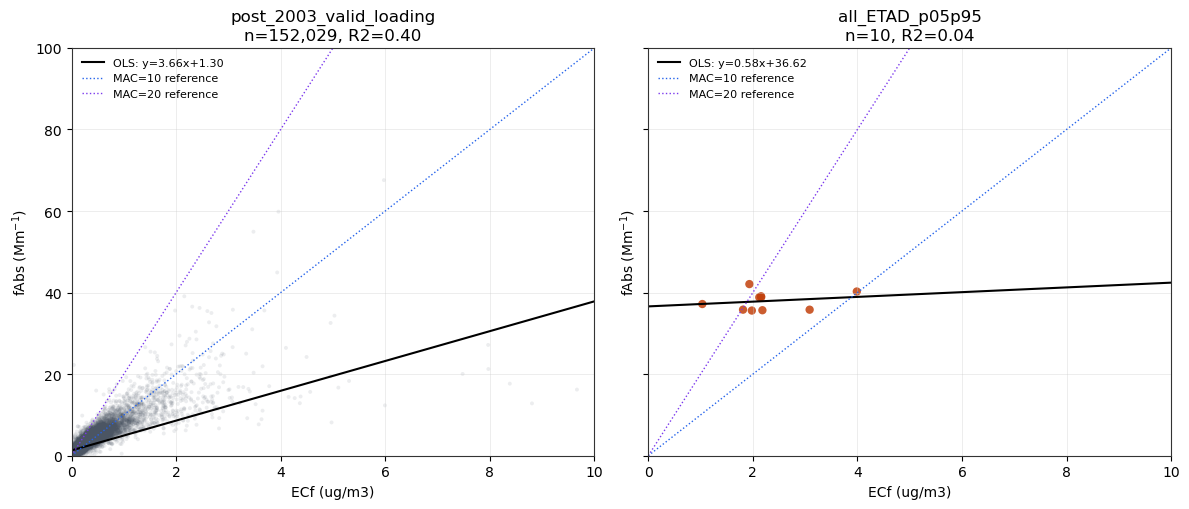

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2), sharex=True, sharey=True)

plot_groups = [
    ('post_2003_valid_loading', groups['post_2003_valid_loading'], axes[0], '#4B5563'),
    ('all_ETAD_p05p95', groups['all_ETAD_p05p95'], axes[1], '#C2410C'),
]

xmax = max(10, post['ECf_Val'].quantile(.995))
ymax = max(100, post['fAbs_Val'].quantile(.999))
for title, df, ax, color in plot_groups:
    if len(df) > 50000:
        draw = df.sample(50000, random_state=42)
    else:
        draw = df
    ax.scatter(draw['ECf_Val'], draw['fAbs_Val'], s=8 if len(draw) > 1000 else 36, alpha=0.10 if len(draw) > 1000 else 0.85, color=color, edgecolor='none', rasterized=True)
    fit = fit_fabs_ec(df)
    xline = np.linspace(0, xmax, 100)
    if np.isfinite(fit['slope']):
        ax.plot(xline, fit['slope'] * xline + fit['intercept'], color='black', lw=1.5, label=f"OLS: y={fit['slope']:.2f}x+{fit['intercept']:.2f}")
    ax.plot(xline, 10 * xline, color='#2563EB', lw=1.0, ls=':', label='MAC=10 reference')
    ax.plot(xline, 20 * xline, color='#7C3AED', lw=1.0, ls=':', label='MAC=20 reference')
    ax.set_title(f'{title}\nn={fit["n"]:,}, R2={fit["r2"]:.2f}')
    ax.set_xlabel('ECf (ug/m3)')
    ax.set_ylabel('fAbs (Mm$^{-1}$)')
    ax.set_xlim(0, xmax)
    ax.set_ylim(0, ymax)
    ax.legend(frameon=False, fontsize=8)

fig.tight_layout()
fig.savefig(OUT_DIR / 'fabs_ec_full_vs_all_bounds.png', dpi=230, bbox_inches='tight')
plt.show()

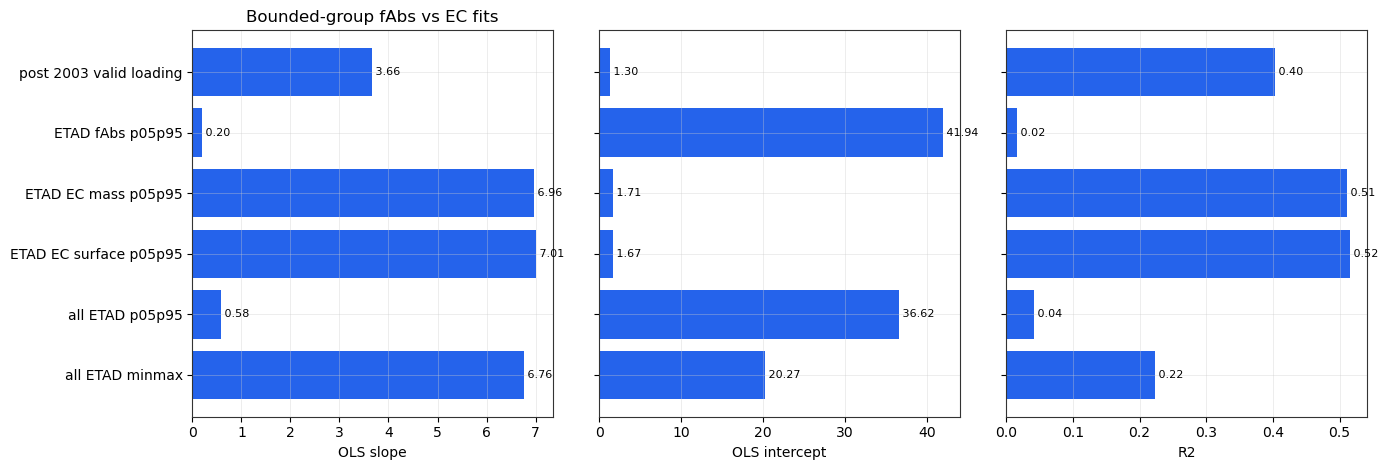

In [12]:
coef_plot = fit_summary.copy()
coef_plot['label'] = coef_plot['group'].str.replace('_', ' ')

fig, axes = plt.subplots(1, 3, figsize=(14, 4.8))
ypos = np.arange(len(coef_plot))
for ax, col, xlabel in [
    (axes[0], 'slope', 'OLS slope'),
    (axes[1], 'intercept', 'OLS intercept'),
    (axes[2], 'r2', 'R2'),
]:
    ax.barh(ypos, coef_plot[col], color='#2563EB')
    ax.set_yticks(ypos)
    ax.set_yticklabels(coef_plot['label'] if ax is axes[0] else [])
    ax.invert_yaxis()
    ax.set_xlabel(xlabel)
    for i, val in enumerate(coef_plot[col]):
        if np.isfinite(val):
            ax.text(val, i, f' {val:.2f}', va='center', fontsize=8)
axes[0].set_title('Bounded-group fAbs vs EC fits')
fig.tight_layout()
fig.savefig(OUT_DIR / 'bounded_group_regression_comparison.png', dpi=220, bbox_inches='tight')
plt.show()

## RT and Blank-Line Caveats

The FED RT fields support an optical-regime screen, but they do **not** reproduce the SPARTAN field-blank calibration-line analysis. In this pull we have ambient-sample final/initial/minimum reflectance/transmittance ratio fields, not the raw field blanks and lot-specific coefficients needed for a true Warren White-style blank-line recalculation.

Use RT results here as diagnostics for whether bounded samples occupy unusual optical space, not as a correction.

In [13]:
rt_cols = ['RefF_635_Val', 'TransF_635_Val', 'RefI_635_Val', 'TransI_635_Val', 'RefM_635_Val', 'TransM_635_Val']
rt_summary_rows = []
for name, df in groups.items():
    rt = df[df['rt_available']].copy()
    row = {
        'group': name,
        'n': len(df),
        'rt_n': len(rt),
        'rt_pct': len(rt) / len(df) * 100 if len(df) else np.nan,
    }
    for col in rt_cols:
        row[f'{col}_median'] = rt[col].median() if col in rt else np.nan
    if {'RefI_635_Val', 'TransI_635_Val', 'RefM_635_Val', 'TransM_635_Val'}.issubset(rt.columns):
        row['initial_t_over_r_median'] = (rt['TransI_635_Val'] / rt['RefI_635_Val']).replace([np.inf, -np.inf], np.nan).median()
        row['min_t_over_r_median'] = (rt['TransM_635_Val'] / rt['RefM_635_Val']).replace([np.inf, -np.inf], np.nan).median()
    rt_summary_rows.append(row)

rt_summary = pd.DataFrame(rt_summary_rows)
rt_summary.to_csv(OUT_DIR / 'rt_availability_and_group_summary.csv', index=False)
display(rt_summary.round(3))

,group,n,rt_n,rt_pct,RefF_635_Val_median,TransF_635_Val_median,RefI_635_Val_median,TransI_635_Val_median,RefM_635_Val_median,TransM_635_Val_median,initial_t_over_r_median,min_t_over_r_median
0,post_2003_valid_loading,152029,145200,95.508,397.420,216.900,353.140,165.490,297.265,70.710,0.495,0.242
1,ETAD_fAbs_p05p95,36,35,97.222,428.050,217.610,192.130,1.930,171.260,0.010,0.011,0.000
2,ETAD_EC_mass_p05p95,7196,6845,95.122,394.150,213.280,239.520,53.820,201.140,7.060,0.236,0.036
3,ETAD_EC_surface_p05p95,7299,6946,95.164,394.165,213.240,239.755,54.245,201.250,7.145,0.238,0.037
4,all_ETAD_p05p95,10,10,100.000,478.490,226.685,214.745,5.070,198.020,0.875,0.030,0.004
5,all_ETAD_minmax,42,40,95.238,405.705,202.270,192.495,4.525,173.180,0.430,0.020,0.002


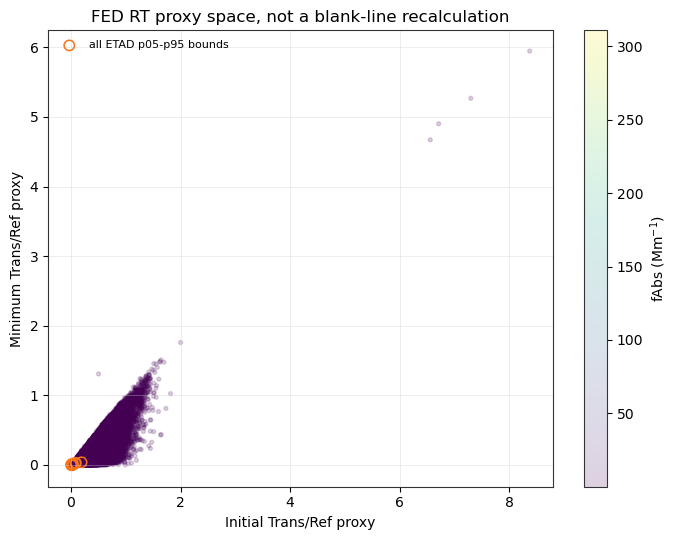

In [14]:
rt_plot = post[post['valid_loading'] & post['rt_available']].copy()
rt_plot['initial_t_over_r'] = (rt_plot['TransI_635_Val'] / rt_plot['RefI_635_Val']).replace([np.inf, -np.inf], np.nan)
rt_plot['min_t_over_r'] = (rt_plot['TransM_635_Val'] / rt_plot['RefM_635_Val']).replace([np.inf, -np.inf], np.nan)
rt_draw = rt_plot.dropna(subset=['initial_t_over_r', 'min_t_over_r', 'fAbs_Val'])
if len(rt_draw) > 60000:
    rt_draw = rt_draw.sample(60000, random_state=42)

fig, ax = plt.subplots(figsize=(7, 5.5))
sc = ax.scatter(rt_draw['initial_t_over_r'], rt_draw['min_t_over_r'], c=rt_draw['fAbs_Val'], s=8, alpha=0.18, cmap='viridis', rasterized=True)
if len(comparable):
    comp_rt = comparable[comparable['rt_available']].copy()
    comp_rt['initial_t_over_r'] = (comp_rt['TransI_635_Val'] / comp_rt['RefI_635_Val']).replace([np.inf, -np.inf], np.nan)
    comp_rt['min_t_over_r'] = (comp_rt['TransM_635_Val'] / comp_rt['RefM_635_Val']).replace([np.inf, -np.inf], np.nan)
    ax.scatter(comp_rt['initial_t_over_r'], comp_rt['min_t_over_r'], s=55, facecolor='none', edgecolor='#F97316', linewidth=1.1, label='all ETAD p05-p95 bounds')
ax.set_xlabel('Initial Trans/Ref proxy')
ax.set_ylabel('Minimum Trans/Ref proxy')
ax.set_title('FED RT proxy space, not a blank-line recalculation')
ax.legend(frameon=False, fontsize=8)
fig.colorbar(sc, ax=ax, label='fAbs (Mm$^{-1}$)')
fig.tight_layout()
fig.savefig(OUT_DIR / 'rt_proxy_space_comparable_filters.png', dpi=230, bbox_inches='tight')
plt.show()

## Readout

Run this cell after the notebook executes. It writes a compact CSV summary for slides and for the Warren/Cena question list.

In [15]:
most_restrictive = audit_counts[audit_counts['group'].isin(['fAbs_p05p95_only', 'EC_mass_p05p95_only', 'EC_surface_p05p95_only'])].sort_values('n').head(1)
readout = pd.DataFrame([
    {'item': 'cleaned_positive_ec_fabs_all_years', 'value': len(improve)},
    {'item': 'post_2003_rows', 'value': len(post)},
    {'item': 'post_2003_valid_loading_rows', 'value': int((post['valid_loading']).sum())},
    {'item': 'all_etad_p05p95_rows', 'value': len(comparable)},
    {'item': 'all_etad_minmax_rows', 'value': len(comparable_minmax)},
    {'item': 'most_restrictive_single_p05p95_bound', 'value': most_restrictive.iloc[0]['group'] if len(most_restrictive) else None},
    {'item': 'most_restrictive_single_p05p95_n', 'value': int(most_restrictive.iloc[0]['n']) if len(most_restrictive) else None},
])
readout.to_csv(OUT_DIR / 'slide_readout_summary.csv', index=False)
display(readout)

print('Interpretation prompts:')
print('- If all ETAD p05-p95 bounds retain few or no IMPROVE rows, Addis/ETAD is outside normal IMPROVE HIPS operating space.')
print('- If EC-loading-matched IMPROVE rows do not reach ETAD fAbs, high EC loading alone is not enough to explain Addis.')
print('- If high-fAbs comparable rows cluster by site/date and have weak fAbs-vs-EC structure, treat them as rare event diagnostics, not a stable calibration population.')
print('- FED RT fields are useful proxies, but raw blank rows and coefficients are still needed for a true blank-line mechanism test.')

,item,value
0,cleaned_positive_ec_fabs_all_years,379697
1,post_2003_rows,379697
2,post_2003_valid_loading_rows,152029
3,all_etad_p05p95_rows,10
4,all_etad_minmax_rows,42
5,most_restrictive_single_p05p95_bound,fAbs_p05p95_only
6,most_restrictive_single_p05p95_n,36


Interpretation prompts:
- If all ETAD p05-p95 bounds retain few or no IMPROVE rows, Addis/ETAD is outside normal IMPROVE HIPS operating space.
- If EC-loading-matched IMPROVE rows do not reach ETAD fAbs, high EC loading alone is not enough to explain Addis.
- If high-fAbs comparable rows cluster by site/date and have weak fAbs-vs-EC structure, treat them as rare event diagnostics, not a stable calibration population.
- FED RT fields are useful proxies, but raw blank rows and coefficients are still needed for a true blank-line mechanism test.
